In [1]:
import pygeotools
import pygeopinn
import matplotlib.pyplot as plt
import cmocean

In [2]:
pygeo = pygeotools.pygeotools()
pinns = pygeopinn.pygeopinn()

pygeotools was initialized with `verbose=True`.
The library was successfully initialized.


In [3]:
# Loading the model
pygeo.loadModel("geodynamo", "pygeodyn_hdf5", "../geodynamo.hdf5")

In [4]:
pygeo.setGrid("10deg")

_, (thetas, phis) = pygeo.getCurrentGrid()

thetas = thetas

context = {"lmax": 13, "r": pygeo.constants["rCore"]}
context_u = {"lmax": 30, "r": pygeo.constants["rCore"]}

MF = pygeo.addMeasure("geodynamo", "MF", context)
SV = pygeo.addMeasure("geodynamo", "SV", context)
U = pygeo.addMeasure("geodynamo", "U", context_u)

dBrdt = SV[-1, ..., 0]
Br = MF[-1, ..., 0]
Uθ = U[-1, ..., 1]
Uφ = U[-1, ..., 2]

13


In [9]:
observations = {
    "dbrdt": dBrdt, "br": Br, "uθ": Uθ, "uφ": Uφ
}

In [10]:
pinns.set_grid(thetas, phis)
pinns.set_observation("br", Br)
pinns.set_observation("dbrdt", dBrdt)

The grid was successfully set.
The observation br was successfully added.
The observation dbrdt was successfully added.


In [11]:
pinns.set_loss("dbrdt", 1)
# pinns.set_loss("br", 1)
pinns.set_loss("geostrophy", 1e2)

The loss dbrdt was successfully added.
The loss geostrophy was successfully added.


In [ ]:
pinns.train(10000)

Everything is ready for the training.


3.16% (04:39 remaining) | Loss = 4.777E-01

In [ ]:
predictions = pinns.evaluate()

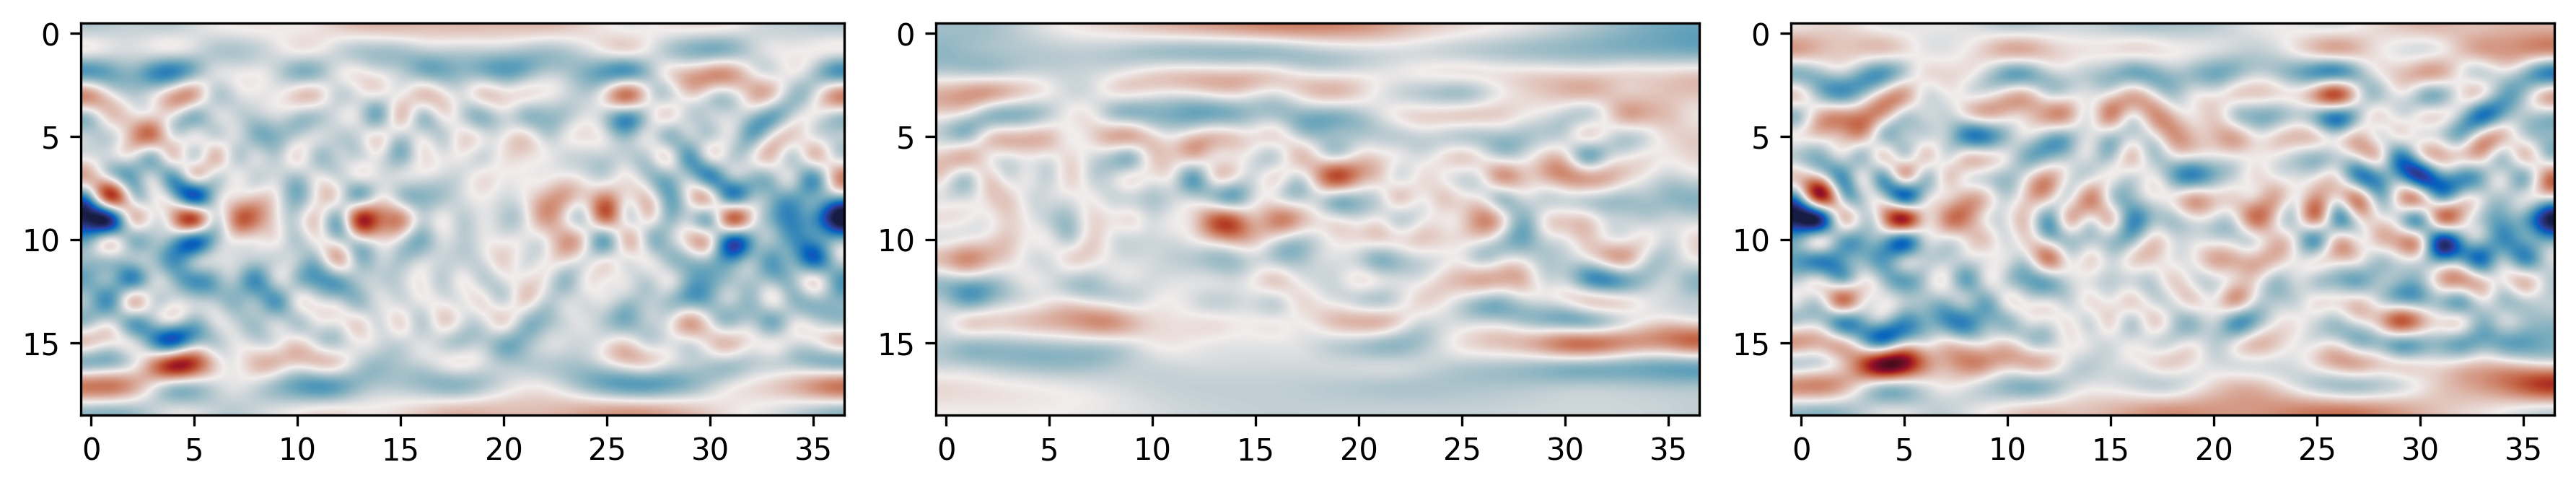

In [ ]:
quantity = "uφ"

fig, axes = plt.subplots(1, 3, dpi=300, figsize=(12, 5))

prediction = predictions[quantity]
observation = observations[quantity]

vmax = max(abs(prediction).max(), abs(observation).max())
kwargs = {"cmap": cmocean.cm.balance, "interpolation": "lanczos", "vmin": -vmax, "vmax": vmax}

axes[0].imshow(observation, **kwargs)
axes[1].imshow(prediction, **kwargs)
axes[2].imshow(observation - prediction, **kwargs)

plt.tight_layout()